In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
from models.linear_probes import linear_probe, linear_probe_tuned
from models.feature_generation import build_feature_bank, extract_encoder, extract_feature,pool_features
from preprocessing.dataset import PipistrelleDataset
from evaluation.metrics import compute_cv_stats,plot_model_comparison,label_confusion
import pandas as pd
from sklearn.metrics import average_precision_score
from evaluation.metrics import compute_metrics,compile_results,generate_metrics_table2,plot_comprehensive_boxplots,plot_comprehensive_mlp_boxplots
from evaluation.metrics import plot_comprehensive_calibration,plot_mlp_balancing_boxplots
from models.MLP_balancing import balancing_mlp,balancing_mlp_val,data_augmented_mlp
import pickle
from pathlib import Path
import os
from evaluation.statistical_tests import perform_encoder_statistical_analysis,evaluate_and_plot_mlp_strategies
from models.abmil_model import abmil_classifier_tuned

c:\Users\artem\AppData\Local\miniconda3\envs\playground\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\artem\AppData\Local\miniconda3\envs\playground\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)
c:\Users\artem\AppData\Local\m

In [3]:
dir = Path(os.getcwd()).resolve().parent 
path = str(dir / "models" / "features")
X_per2 = np.load(path + "\\perch_features.npz")['features']
X_per2_pooled = X_per2
y = np.load(path + "\\perch_features.npz")['labels']
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

In [4]:
with open(path + "\\bat_features_mil.pkl",'rb') as f :
    loaded_features = pickle.load(f) 
X_bags = pool_features(loaded_features, windows  = False,window_pooled  = False, method  ='mean',encoder  = 'perch2')

In [5]:
print(len(X_bags))

284


In [ ]:
abmil_results = abmil_classifier_tuned(X_bags, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42,n_iter_search = 4)

In [6]:
per2_results = linear_probe_tuned(X_per2_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Logistic Regression
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating 

In [ ]:
ab2_results = abmil_results

In [ ]:
from evaluation.metrics import plot_abmil_vs_perch_boxplots

plot_abmil_vs_perch_boxplots(abmil_results, per2_results, label_names=label_names)

In [ ]:
from evaluation.statistical_tests import evaluate_abmil_vs_perch_statistical
evaluate_abmil_vs_perch_statistical(abmil_results, per2_results, label_names=label_names)

In [ ]:
abmil_results_feats3 = abmil_classifier_tuned(X_bags, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42,n_iter_search = 4,hybrid = True)

In [ ]:
from evaluation.metrics import compile_results_folds
ab_compiled_result3 = compile_results(abmil_results_feats3,label_names=None,stats= True,encoder = 'perch2')
generate_metrics_table2(ab_compiled_result3 ,label_names=label_names)

In [ ]:
plot_abmil_vs_perch_boxplots(abmil_results_feats3, per2_results, label_names=label_names)

In [ ]:
evaluate_abmil_vs_perch_statistical(abmil_results_feats3, per2_results, label_names=label_names)

In [ ]:
per2_results2 = linear_probe_tuned(X_per2_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

In [ ]:
plot_abmil_vs_perch_boxplots(abmil_results_feats3, per2_results2, label_names=label_names)

In [18]:
def extract_essential_results(results):
    """Strip PyTorch objects, keep only numpy arrays and metrics."""
    clean = []
    for trial_result in results:
        clean.append({
            'trial': trial_result['trial'],
            'model': trial_result['model'],
            'mean_AP': trial_result['mean_AP'],
            'std_AP': trial_result['std_AP'],
            'y_true_cv': trial_result['y_true_cv'],
            'y_pred_proba_cv': trial_result['y_pred_proba_cv'],
            'oof_y_true': trial_result['oof_y_true'],
            'oof_y_pred_proba': trial_result['oof_y_pred_proba'],
            'oof_indices': trial_result['oof_indices'],
            'train_histories': trial_result['train_histories'],
            'val_histories': trial_result['val_histories'],
            # Deliberately exclude 'best_models' — contains PyTorch objects
        })
    return clean

In [ ]:
import pickle

pickle_filename = 'abmil_results.pkl'
with open(pickle_filename, 'wb') as pickle_file:
    pickle.dump(extract_essential_results(abmil_results), pickle_file)
pickle_filename = 'abmil_results_feats.pkl'
with open(pickle_filename, 'wb') as pickle_file:
    pickle.dump(extract_essential_results(abmil_results_feats3), pickle_file)

In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

In [16]:

abmil_results_ensemble = abmil_classifier_tuned(X_bags, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42,n_iter_search = 4,ensemble=True)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: ABMIL
    Evaluating fold 1/5
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Early stopping at epoch 14
[CV 1/5] END attention_dim=128, dropout=0.1, ensemble_alpha=0.0, hidden_dim=256, learning_rate=0.0021118915966823948, lr_C=0.1, weight_decay=4.2079886696066345e-06;, score=nan total time=  13.7s
Early stopping at epoch 20
[CV 2/5] END attention_dim=128, dropout=0.1, ensemble_alpha=0.0, hidden_dim=256, learning_rate=0.0021118915966823948, lr_C=0.1, weight_decay=4.2079886696066345e-06;, score=nan total time=  19.3s
Early stopping at epoch 11
[CV 3/5] END attention_dim=128, dropout=0.1, ensemble_alpha=0.0, hidden_dim=256, learning_rate=0.0021118915966823948, lr_C=0.1, weight_decay=4.2079886696066345e-06;, score=nan total time=  10.8s
Early stopping at epoch 11
[CV 4/5] END attention_dim=128, dropout=0.1, ensemble_alpha=0.0, hidden_dim=256, learning_rate=0.0021118915966823948, lr_C=0.1, weight_decay=4.

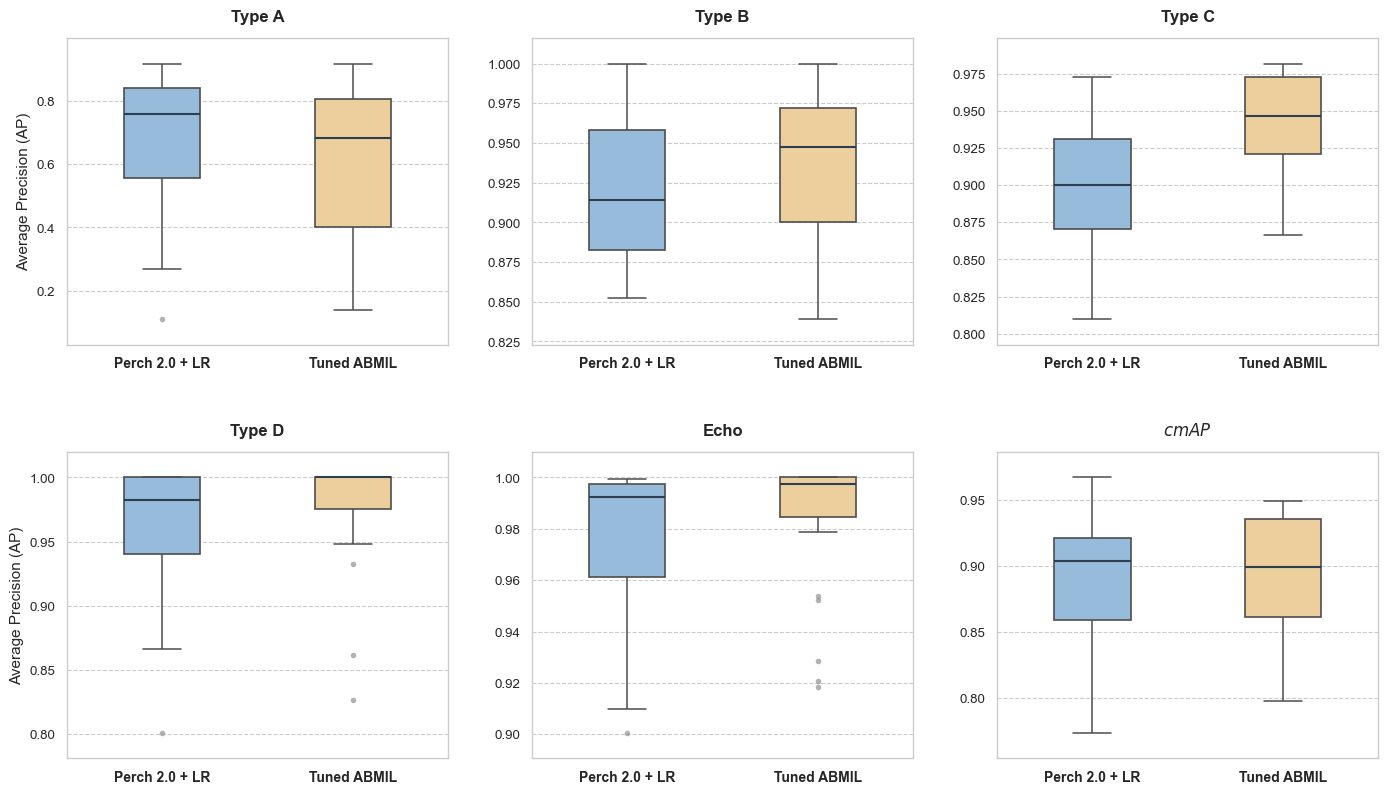

In [17]:
from evaluation.metrics import plot_abmil_vs_perch_boxplots
plot_abmil_vs_perch_boxplots(abmil_results_ensemble, per2_results, label_names=label_names)

In [19]:
import pickle
pickle_filename = 'abmil_results_ensemble.pkl'
with open(pickle_filename, 'wb') as pickle_file:
    pickle.dump(extract_essential_results(abmil_results_ensemble), pickle_file)